# 3. Data analysis

In this notebook we use our benchmarking data to predict the scaling behaviour of measured fidelity with circuit depth. We then determine whether the results of our kicked-Ising circuits fit this prediction. 

In [1]:
# Initial imports:

import numpy as np
import sys
sys.path.append('../')
Ls = np.load('../layers.npy')

from scipy.optimize import curve_fit

from matplotlib import pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerPatch
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'

Function to count the number of two-qubit gates in the lightcone of an observable, given the circuit and the qubits measured. 

In [2]:
def num_2q_gates_in_lightcone(circuit_gates, measured_qubits):

    gates = circuit_gates[::-1]

    lightcone_qubits = measured_qubits
    lightcone_circuit_gates = []

    for gate in gates:

        if len(gate[1]) == 1:
            if gate[1][0] in lightcone_qubits:
                lightcone_circuit_gates.append(gate)

        if len(gate[1]) == 2:
            q0, q1 = gate[1]
            if q0 in lightcone_qubits or q1 in lightcone_qubits:
                if q0 not in lightcone_qubits:
                    lightcone_qubits.append(q0)
                if q1 not in lightcone_qubits:
                    lightcone_qubits.append(q1)
                lightcone_circuit_gates.append(gate)

    return sum([1 for gate in lightcone_circuit_gates if len(gate[0])==2])

We first perform an analysis of our benchmarking data.

In [3]:
# Import data:

benchmarking_parameters = np.load('benchmarking_parameters.npy', allow_pickle=True)
benchmarking_job_data = np.load('benchmarking_job_data_brisbane.npy')

In [4]:
# Create a dictionary of 1050 tuples (V, fidelity), sorted by number of qubits in circuit
# V = num 2 qubit gates in lightcone


V_fid_tuples = {}
for i in [2,4,8,16,32,64,127]:
    V_fid_tuples[i] = []

counter = 0
for int_qubits in range(7):
    for int_layers in range(15):
        for int_experiment_rep in range(10):
            
            # Import benchmarking params
            device_qubits, pauli_to_measure, circuit_gates = benchmarking_parameters[int_qubits][int_layers][int_experiment_rep]
            N = len(pauli_to_measure)
            fid = benchmarking_job_data[counter]
            
            # Calculate V
            measured_qubits = [device_qubits[i] for i in range(len(device_qubits)) if pauli_to_measure[i] != 'I']
            V = num_2q_gates_in_lightcone(circuit_gates, measured_qubits)
            
            # Save V, fid
            tuples_list = V_fid_tuples[N]
            tuples_list.append([V,fid])
            V_fid_tuples[N] = tuples_list

            counter += 1

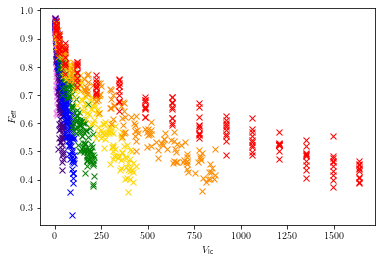

In [5]:
# Plot benchmarking data (V, F_eff) with datapoints coloured by number of qubits in circuit
colours = {2:'violet',4:'indigo',8:'blue',16:'green',32:'gold',64:'darkorange',127:'red'}
for i in [2,4,8,16,32,64,127]:
    tuples_list = V_fid_tuples[i]
    for x, y in tuples_list:
        plt.plot(x,y,'x',color=colours[i])
plt.xlabel(r'$V_\text{lc}$')
plt.ylabel(r'$F_\text{eff}$');

We perform two kinds of data analysis:
1. Fit the $(V/N, F_{\text{eff}})$ data to a degree-2 polynomial (red line). 
2. Shade the region three standard deviations above and below the fitted polynomial (red shaded region). For $M$ equally-spaced $x$-values between 0 and 14 (i.e. 0, 14/M, 2 x 14/M, ..., M x 14/M), we calculate the standard deviation of all data between $x-1$ and $x+1$ to determine the height of the shaded region at that $x$ value. 

In [6]:
# Fit benchmarking data to degree-2 polynomial


# Separate data into X, Y parts
X_data = []
Y_data = []
for i in [2,4,8,16,32,64,127]:
    tuples_list = V_fid_tuples[i]
    for x, y in tuples_list:
        X_data.append(x/i)
        Y_data.append(y)   
        
# Fit using scipy.optimize.curve_fit
def poly(x, a, b, c):
    return   a * x**2 + b*x + c

popt, pcov = curve_fit(poly, X_data, Y_data)
x_fit = np.linspace(0, 14, 100)
y_fit = [poly(x, *popt) for x in x_fit]

In [7]:
# Determine shaded region


# Number of x-values 
M = 100

# Group data into M groups by x-value
y_data_grouped = {i:[] for i in range(M)}
for i in range(M):
    for j in range(len(X_data)):
        x_val = X_data[j]
        if x_val >= 14*i/M-1 and x_val <= 14*i/M+1:
            y_list = y_data_grouped[i]
            y_list.append(Y_data[j])
# Calculate standard deviations of the groups
y_stds = [np.std(y_data_grouped[i]) for i in range(M)]
# Calculate 3 standard deviations below and above the fitted polynomial
y_lower = [poly(14*i/M,*popt)-3*y_stds[i] for i in range(M)] + [poly(14,*popt)-3*y_stds[-1]]
y_upper = [poly(14*i/M,*popt)+3*y_stds[i] for i in range(M)] + [poly(14,*popt)+3*y_stds[-1]]
fill_x = [14*i/M for i in range(M)] + [14]

Text(0.5, 1.0, 'Benchmarking data')

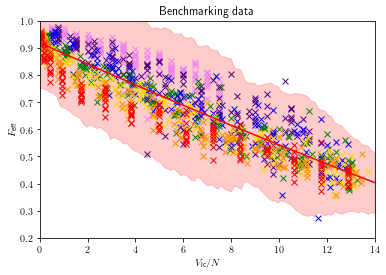

In [8]:
# Plot results


# Red shaded region
plt.fill_between(fill_x, y_lower, y_upper, color='red', alpha=0.2, label='3$\sigma$ prediction margin')

# Datapoints
for i in [2,4,8,16,32,64,127]:
    tuples_list = V_fid_tuples[i]
    for x, y in tuples_list:
        plt.plot(x/i,y,'x',color=colours[i])
        
# Red fitted curve
plt.plot(x_fit, y_fit, color='red')

plt.ylim([0.2, 1])
plt.xlim([0,14]);
plt.xlabel(r'$V_\text{lc}/N$')
plt.ylabel(r'$F_\text{eff}$');
plt.title('Benchmarking data')

Now we handle the kicked-Ising data. We first import the data and calculate the measured fidelity for each of the 900 kicked-Ising circuits, as well as the $V/N$ x-value. We filter the data by removing high-variance datapoints and those with $F_\text{eff}$ above 1 or below 0, and then overlay with the predictions of the benchmarking data above. 

In [9]:
def IBM_gates_list(device_qubits, n_layers):
    
    gates_list = []
    N = len(device_qubits)
    
    for layer in range(n_layers):
        # Rx on each qubit
        for i in range(N):
            gates_list.append(['X',[i]])
            
        # Rzz over 3 layers
        for Li in Ls:
            for q0, q1 in Li:
                if q0 in device_qubits and q1 in device_qubits:
                    gates_list.append(['ZZ',[q0,q1]])

    return gates_list

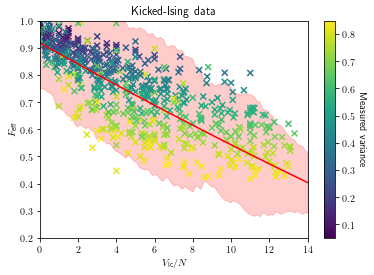

In [10]:
# Load kicked-Ising data, remove high-variance datapoints and fix values below 0 / above 1

ki_parameters = np.load('KI_parameters.npy', allow_pickle=True)
ki_job_data = np.load('KI_job_data_brisbane.npy')

# Process each circuit individually, calculating x-value (V/N), y-value (F_eff)
# and checking variance is below threshold 

ki_X_data = []
ki_Y_data = []
variance_threshold = 0.85
variances_filtered = []

for i in range(900):
    
    variance = ki_job_data[i][1]
    
    # If measured variance below threshold
    if  variance < variance_threshold:
    
        variances_filtered.append(variance)
    
        # Calculate V/N
        device_qubits, pauli_to_measure, n_layers, angle, exact_val = ki_parameters[i]
        gates_list = IBM_gates_list(device_qubits, n_layers)
        V = num_2q_gates_in_lightcone(gates_list, [62])
        N = len(device_qubits)
        ki_X_data.append(V/N)

        # Calculate F_eff
        measured_val = ki_job_data[i][0]
        ki_Y_data.append(measured_val/exact_val)

        

plt.fill_between(fill_x, y_lower, y_upper, color='red', alpha=0.2, label='3$\sigma$ prediction margin')

plt.scatter(ki_X_data, ki_Y_data, marker='x', c=variances_filtered, cmap='viridis', label='kicked-Ising circuits')
cbar = plt.colorbar()
cbar.set_label(r'Measured variance', rotation=270, labelpad=12)

plt.plot(x_fit, y_fit, color='red')
plt.title('Kicked-Ising data')
plt.xlabel(r'$V_\text{lc}/N$')
plt.ylabel(r'$F_\text{eff}$');
plt.ylim([0.2,1])
plt.xlim([0,14]);

Finally, we combine all of the above into a single plot and add custom legends. 

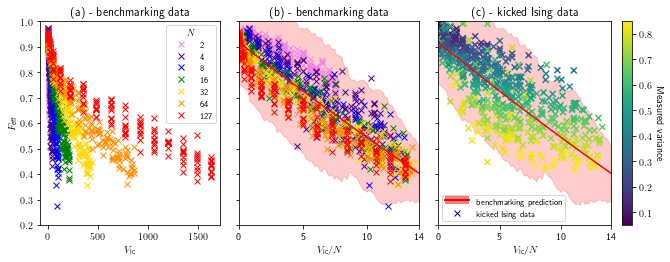

In [11]:
markers = [mlines.Line2D([], [], color=colours[i], marker='x', ls='', label=str(i)) for i in [2,4,8,16,32,64,127]]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(9.5, 3.75), gridspec_kw={'width_ratios': [1, 1, 1.2]})

# Plot 1
for i in [2,4,8,16,32,64,127]:
    tuples_list = V_fid_tuples[i]
    for x, y in tuples_list:
        ax1.plot(x,y,'x',color=colours[i])
        
# Plot 2    
ax2.fill_between(fill_x, y_lower, y_upper, color='red', alpha=0.2, label='3$\sigma$ prediction margin')

for i in [2,4,8,16,32,64,127]:
    tuples_list = V_fid_tuples[i]
    for x, y in tuples_list:
        ax2.plot(x/i,y,'x',color=colours[i])
        
ax2.plot(x_fit, y_fit, color='red')

# Plot 3
ax3.fill_between(fill_x, y_lower, y_upper, color='red', alpha=0.2, label='3$\sigma$ prediction margin')
ax3scatter = ax3.scatter(ki_X_data, ki_Y_data, marker='x', c=variances_filtered, cmap='viridis', label='kicked-Ising circuits')
ax3.plot(x_fit, y_fit, color='red')


# Labels, legends etc.

ax1legend = ax1.legend(loc='upper right', handles=markers, title='$N$',
                      title_fontsize='9', fontsize='8', markerscale=1, handlelength=3, handleheight=1)
ax1legend.get_title().set_ha('center')
ax1.set_xlabel(r'$V_\text{lc}$')
ax1.set_ylabel(r'$F_{\text{eff}}$')

ax2.set_xlabel(r'$V_\text{lc}/N$')

cbar = plt.colorbar(ax3scatter)
cbar.set_label(r'Measured variance', rotation=270, labelpad=12)
ax3.set_xlabel(r'$V_\text{lc}/N$')


class HandlerCombinedRectangle(HandlerPatch):
    def create_artists(self, legend, orig_handle, x0, y0, width, height, fontsize, trans):
        line = mpatches.Rectangle([x0, y0], width, height, facecolor='lightcoral', edgecolor='none')
        line2 = plt.Line2D([x0, x0+width], [y0+height/2, y0+height/2], color='red', lw=2)
        return [line, line2]

combined_legend_entry = mpatches.Rectangle((0, 0), 1, 1, facecolor="lightcoral", edgecolor="darkred")
legend = ax3.legend(handles=[combined_legend_entry, plt.Line2D([], [], color='darkblue', marker='x', linestyle='none'), 
                    plt.Line2D([], [], color='teal', marker='x', linestyle='none')],
                    labels=['benchmarking prediction', 'kicked Ising data'],
                    handler_map={combined_legend_entry: HandlerCombinedRectangle()}, loc='lower left',
                    title_fontsize='9', fontsize='8', markerscale=1, handlelength=3, handleheight=1)

for ax in [ax2, ax3]:
    ax.set_xlim([0, 14])
    ax.set_xticks([0, 5, 10, 14])
    ax.set_xticklabels([0, 5, 10, 14])
    
for ax in [ax1, ax2, ax3]:
    ax.set_ylim([0.2,1])

ax1.set_title('(a) - benchmarking data')
ax2.set_title('(b) - benchmarking data')
ax3.set_title('(c) - kicked Ising data')

plt.tight_layout()

plt.savefig('fidelities_brisbane.pdf')
plt.show()